In [2]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
import seaborn as sns 

In [3]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000,centers=3,n_features=2,random_state=42)


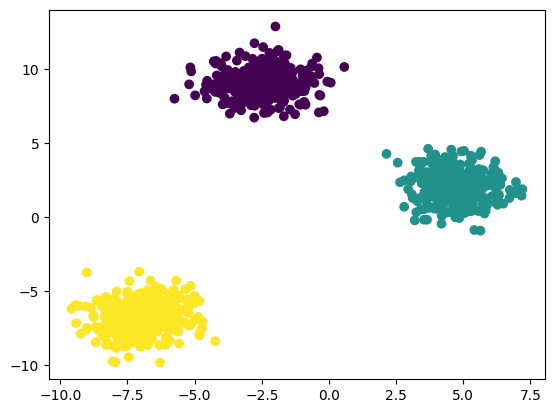

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [5]:

from sklearn.model_selection import train_test_split

X_train, X_test , y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.33)


In [6]:
from  sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[ 1.04850102,  0.11123111],
       [-0.79112419, -1.32318965],
       [ 1.29440146,  0.19161242],
       ...,
       [-0.08501693,  1.21280512],
       [ 1.30478302,  0.04177378],
       [-1.12853504, -1.56809142]], shape=(670, 2))

In [7]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):
    model = KMeans(n_clusters=k,init="k-means++")
    model.fit(X_train_scaled)
    wcss.append(model.inertia_)

wcss

[1339.9999999999998,
 424.77950428412703,
 43.53781728348884,
 36.76344369040307,
 31.656966709998354,
 25.882714368454806,
 26.594228439527477,
 21.515034293242387,
 19.37279132277529,
 18.091231983394028]

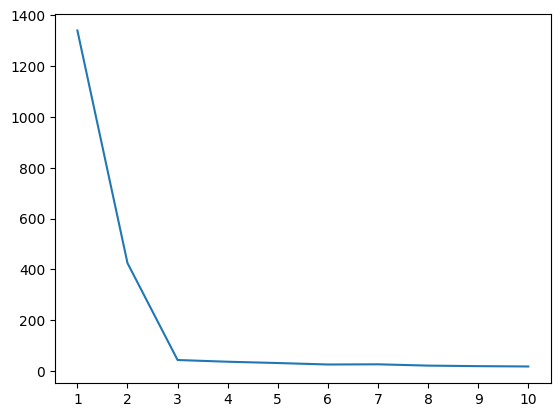

In [8]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.show()

In [9]:
kmeans = KMeans(n_clusters=3,init="k-means++")
kmeans.fit(X_train_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [10]:
y_pred = kmeans.predict(X_test_scaled) 

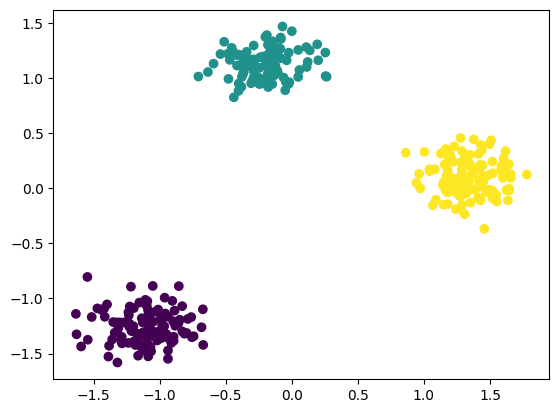

In [11]:
plt.scatter(X_test_scaled[:,0],X_test_scaled[:,1],c=y_pred)
plt.show()

# Knee Locator

In [14]:
from kneed import KneeLocator

kl = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

kl.elbow

np.int64(3)

# silhoutte Scoring

In [16]:
from sklearn.metrics import silhouette_score

silhouette_coeff = []

for k in range(2,11):
    model = KMeans(n_clusters=k,init="k-means++")
    model.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,model.labels_)
    silhouette_coeff.append(score)

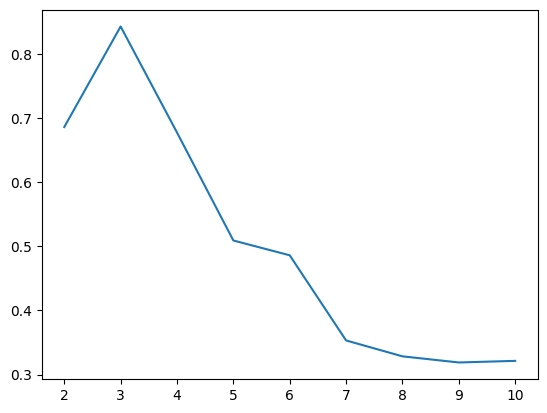

In [18]:
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))
plt.show()